### SCENARIO VARIATION STUDY - CROSS SCENARIO COMPARISON
___

Cluster labels: 
* 0 – Core Frontline Operations Staff (E&I)
* 1 – Specialized Technical Field Experts (E&I)
* 2 – Advanced Governance & Support Specialists
* 3 – Essential Infrastructure Field Crew (E&I)
* 4 – Strategic Business & Real Estate Leaders
* 5 – Governance & Support 

Overview of scenario types:
* Scenario A – Intended Baseline
* Scenario B – Periodic Quota Continuation
* Scenario C – Extended Retirement Age
* Scenario D – Extended Retirement + Periodic Quota
* Scenario E – Accelerated Outsourcing
* Scenario F – Complete No Quota

Seven focused plots:
* Four core narrative:
    1. Crisis State Timeline
    2. Total Workforce Headcount
    3. E&I Score — Cluster 1 (Specialized Technical)
    4. E&I Score — Cluster 0 (Core Frontline Operations Staff)
    5. Future Readiness Index — E&I
* Two Supporting evidence:
    1. Annual Hires vs Retirees
    2. Senior-to-Junior Ratio — Cluster 1

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches

___
CORE NARRATIVES

In [2]:
#LOAD THE COMBINED DATASET
path = 'SCENARIOAF.csv'
master = pd.read_csv(path)

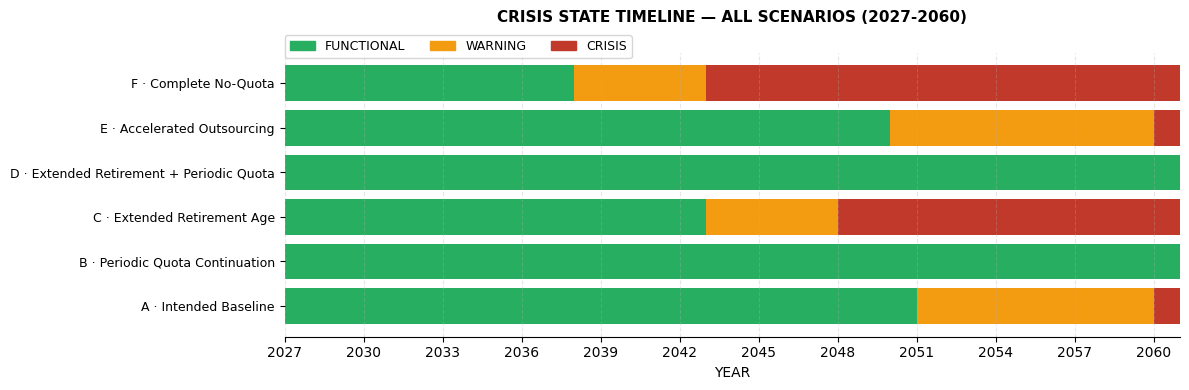

In [3]:
# CROSS-SCENARIO COMPARISON — PLOT 1 · CRISIS STATE TIMELINE · ALL SCENARIOS
SLABELS = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota Continuation',
    2: 'C · Extended Retirement Age',
    3: 'D · Extended Retirement + Periodic Quota',
    4: 'E · Accelerated Outsourcing',
    5: 'F · Complete No-Quota',
}
SCOLOURS = {0: '#27AE60', 1: '#F39C12', 2: '#C0392B'}
STATE  = {0: 'FUNCTIONAL', 1: 'WARNING', 2: 'CRISIS'}
fig, ax = plt.subplots(figsize=(12, 4))
for sid, label in SLABELS.items():
    df = master[master['scenarioID'] == sid].copy()
    for _, row in df.iterrows():
        ax.barh(y=sid, width=1, left=row['year'], color=SCOLOURS[row['crisisState']], edgecolor='none')

patches = [mpatches.Patch(color=SCOLOURS[s], label=STATE[s]) for s in [0, 1, 2]]
ax.legend(handles=patches, fontsize=9, loc='lower left', bbox_to_anchor=(0.0, 0.98), ncol=3, borderaxespad=0)
ax.set_title('CRISIS STATE TIMELINE — ALL SCENARIOS (2027-2060)', fontsize=11, fontweight='bold', pad=22)
ax.set_xlabel('YEAR')
ax.set_xlim(2027, 2061)
ax.set_xticks(range(2027, 2061, 3))
ax.set_yticks(range(6))
ax.set_yticklabels(list(SLABELS.values()), fontsize=9)
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('F6.png', dpi=600, bbox_inches='tight')
plt.show();

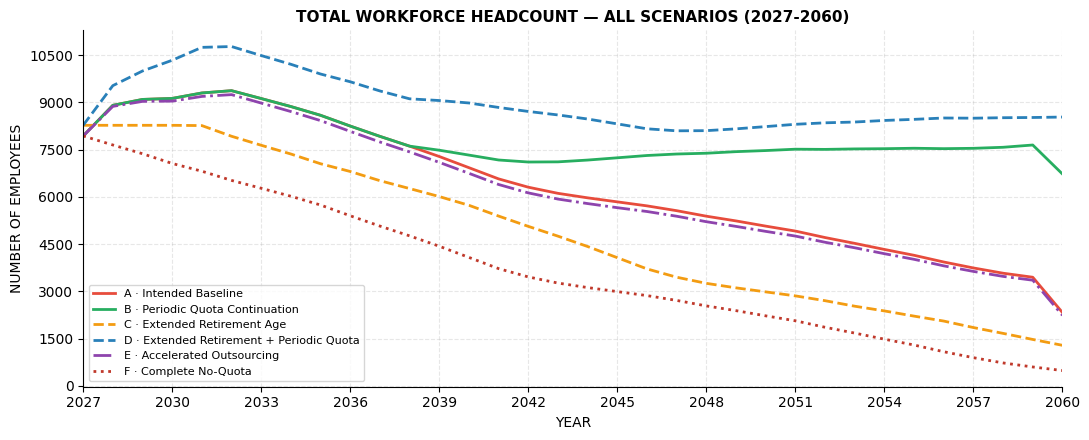

In [4]:
# CROSS-SCENARIO COMPARISON — PLOT 2 · TOTAL WORKFORCE HEADCOUNT · ALL SCENARIOS
SLABELS = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota Continuation',
    2: 'C · Extended Retirement Age',
    3: 'D · Extended Retirement + Periodic Quota',
    4: 'E · Accelerated Outsourcing',
    5: 'F · Complete No-Quota',
}
SCOLOURS = {
    0: '#E74C3C',
    1: '#27AE60',
    2: '#F39C12',
    3: '#2980B9',
    4: '#8E44AD',
    5: '#C0392B',
}
LSTYLES = {
    0: '-',
    1: '-',
    2: '--',
    3: '--',
    4: '-.',
    5: ':',
}

fig, ax = plt.subplots(figsize=(11, 4.5))
for sid, l in SLABELS.items():
    df = master[master['scenarioID'] == sid].copy()
    total = df['count_0'] + df['count_1'] + df['count_2'] + df['count_3'] + df['count_4'] + df['count_5']
    ax.plot(df['year'], total, color=SCOLOURS[sid], linewidth=2, linestyle=LSTYLES[sid], label=l)
ax.set_title('TOTAL WORKFORCE HEADCOUNT — ALL SCENARIOS (2027-2060)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2027, 2060)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

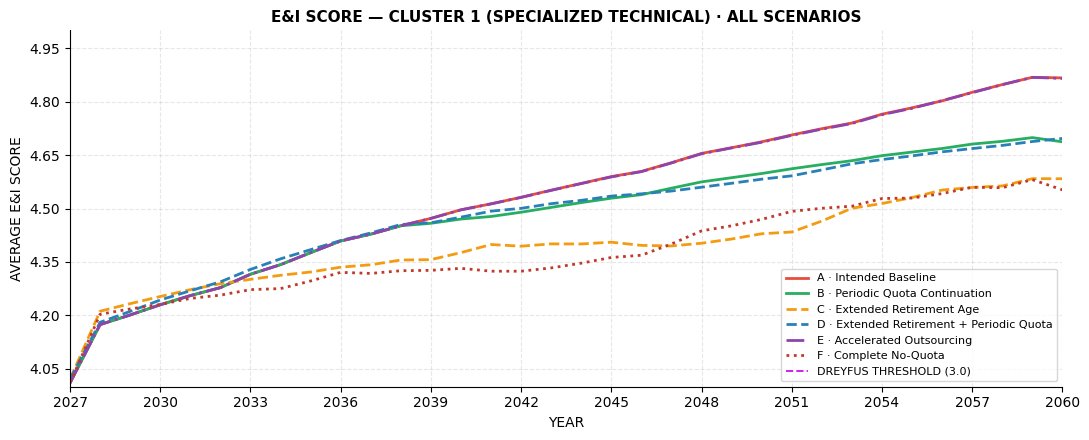

In [ ]:
# CROSS-SCENARIO COMPARISON — PLOT 3A · E&I SCORE — CLUSTER 1 · ALL SCENARIOS
SLABELS = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota Continuation',
    2: 'C · Extended Retirement Age',
    3: 'D · Extended Retirement + Periodic Quota',
    4: 'E · Accelerated Outsourcing',
    5: 'F · Complete No-Quota',
}
SCOLOURS = {
    0: '#E74C3C',
    1: '#27AE60',
    2: '#F39C12',
    3: '#2980B9',
    4: '#8E44AD',
    5: '#C0392B',
}
LSTYLES = {
    0: '-',
    1: '-',
    2: '--',
    3: '--',
    4: '-.',
    5: ':',
}
DREYFUS = 3.0
fig, ax = plt.subplots(figsize=(11, 4.5))
for sid, l in SLABELS.items():
    df = master[master['scenarioID'] == sid].copy()
    ax.plot(df['year'], df['avgEI_1'], color=SCOLOURS[sid], linewidth=2, linestyle=LSTYLES[sid], label=l)
ax.axhline(DREYFUS, color='#CF20EE', linewidth=1.4, linestyle='--', label='DREYFUS THRESHOLD (3.0)')
ax.set_title('E&I SCORE — CLUSTER 1 (SPECIALIZED TECHNICAL) · ALL SCENARIOS', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('AVERAGE E&I SCORE')
ax.set_xlim(2027, 2060)
ax.set_ylim(4.0, 5.0)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

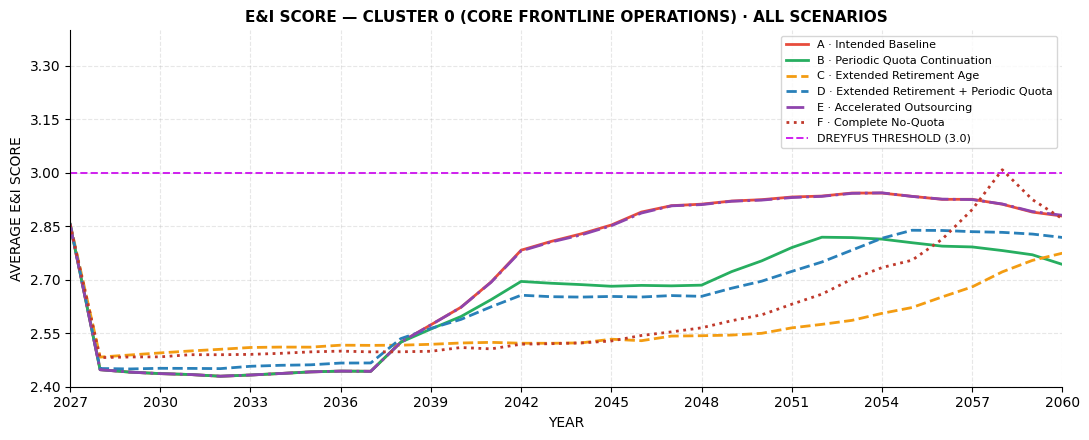

In [ ]:
# CROSS-SCENARIO COMPARISON — PLOT 3B · E&I SCORE — CLUSTER 0 · ALL SCENARIOS
SLABELS = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota Continuation',
    2: 'C · Extended Retirement Age',
    3: 'D · Extended Retirement + Periodic Quota',
    4: 'E · Accelerated Outsourcing',
    5: 'F · Complete No-Quota',
}
SCOLOURS = {
    0: '#E74C3C',
    1: '#27AE60',
    2: '#F39C12',
    3: '#2980B9',
    4: '#8E44AD',
    5: '#C0392B',
}
LSTYLES = {
    0: '-',
    1: '-',
    2: '--',
    3: '--',
    4: '-.',
    5: ':',
}
DREYFUS = 3.0
fig, ax = plt.subplots(figsize=(11, 4.5))
for sid, l in SLABELS.items():
    df = master[master['scenarioID'] == sid].copy()
    ax.plot(df['year'], df['avgEI_0'], color=SCOLOURS[sid], linewidth=2, linestyle=LSTYLES[sid], label=l)
ax.axhline(DREYFUS, color='#CF20EE', linewidth=1.4, linestyle='--', label='DREYFUS THRESHOLD (3.0)')
ax.set_title('E&I SCORE — CLUSTER 0 (CORE FRONTLINE OPERATIONS) · ALL SCENARIOS', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('AVERAGE E&I SCORE')
ax.set_xlim(2027, 2060)
ax.set_ylim(2.4, 3.4)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('F7.png', dpi=600, bbox_inches='tight')
plt.show();

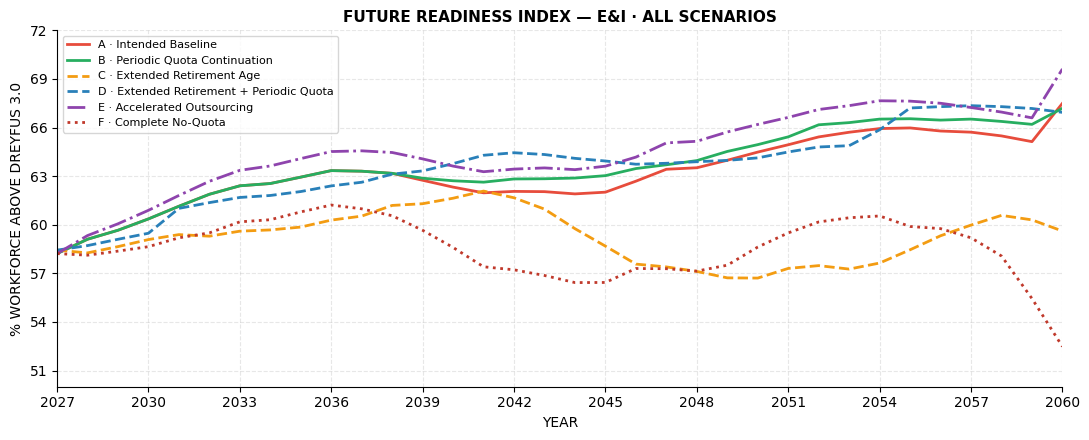

In [14]:
# CROSS-SCENARIO COMPARISON — PLOT 4 · FUTURE READINESS INDEX — E&I · ALL SCENARIOS
SLABELS = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota Continuation',
    2: 'C · Extended Retirement Age',
    3: 'D · Extended Retirement + Periodic Quota',
    4: 'E · Accelerated Outsourcing',
    5: 'F · Complete No-Quota',
}
SCOLOURS = {
    0: '#E74C3C',
    1: '#27AE60',
    2: '#F39C12',
    3: '#2980B9',
    4: '#8E44AD',
    5: '#C0392B',
}
LSTYLES = {
    0: '-',
    1: '-',
    2: '--',
    3: '--',
    4: '-.',
    5: ':',
}
fig, ax = plt.subplots(figsize=(11, 4.5))
for sid, l in SLABELS.items():
    df = master[master['scenarioID'] == sid].copy()
    ax.plot(df['year'], df['friEI'] * 100, color=SCOLOURS[sid], linewidth=2, linestyle=LSTYLES[sid], label=l)
ax.set_title('FUTURE READINESS INDEX — E&I · ALL SCENARIOS', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('% WORKFORCE ABOVE DREYFUS 3.0')
ax.set_xlim(2027, 2060)
ax.set_ylim(50, 72)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

___
SUPPORTING EVIDENCE

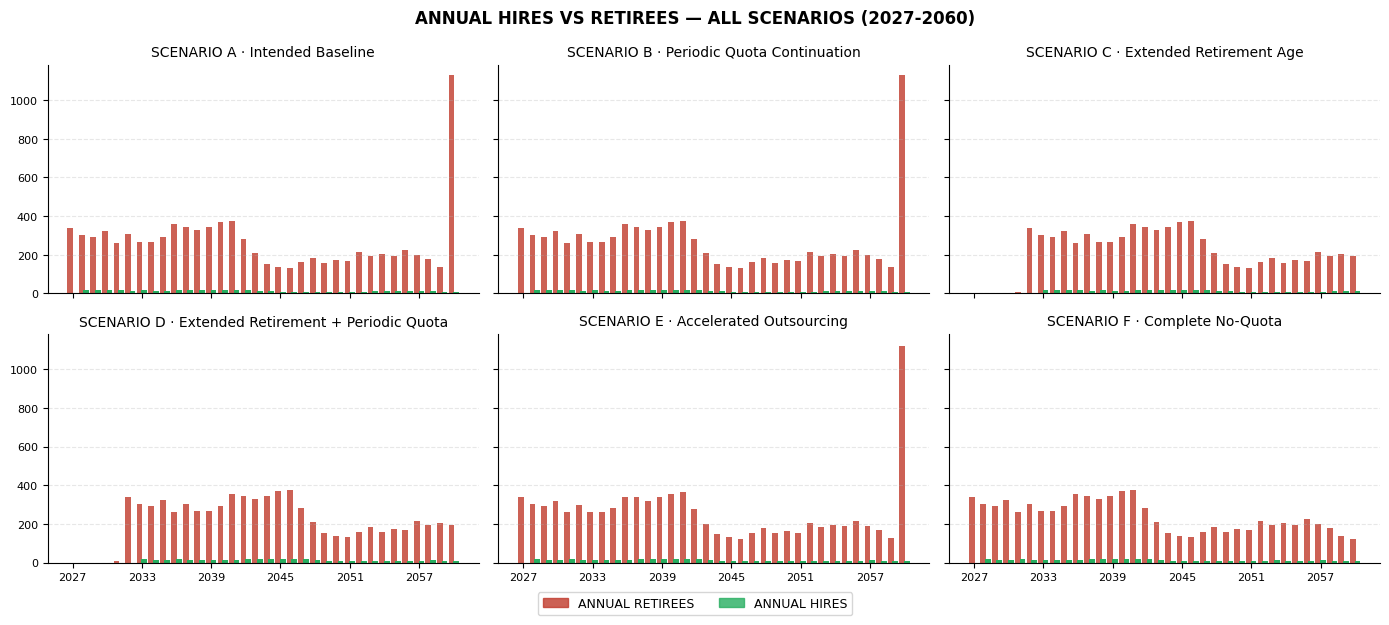

In [27]:
# CROSS-SCENARIO COMPARISON — PLOT 5 · ANNUAL HIRES VS RETIREES · ALL SCENARIOS
SLABELS = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota Continuation',
    2: 'C · Extended Retirement Age',
    3: 'D · Extended Retirement + Periodic Quota',
    4: 'E · Accelerated Outsourcing',
    5: 'F · Complete No-Quota',
}
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.flatten()
for sid, label in SLABELS.items():
    df = master[master['scenarioID'] == sid].copy()
    ax = axes[sid]
    ax.bar(df['year'] - 0.2, df['annualRetireeCount'], width=0.5, color='#C0392B', alpha=0.8, label='RETIREES')
    ax.bar(df['year'] + 0.2, df['annualHireCount'], width=0.5, color='#27AE60', label='HIRES')
    ax.set_title(f'SCENARIO {label}', fontsize=10)
    ax.set_xticks(range(2027, 2061, 6))
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    sns.despine(ax=ax)
handles = [
    mpatches.Patch(color='#C0392B', alpha=0.8, label='ANNUAL RETIREES'),
    mpatches.Patch(color='#27AE60', alpha=0.8, label='ANNUAL HIRES'),
]
fig.legend(handles=handles, fontsize=9, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('ANNUAL HIRES VS RETIREES — ALL SCENARIOS (2027-2060)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show();

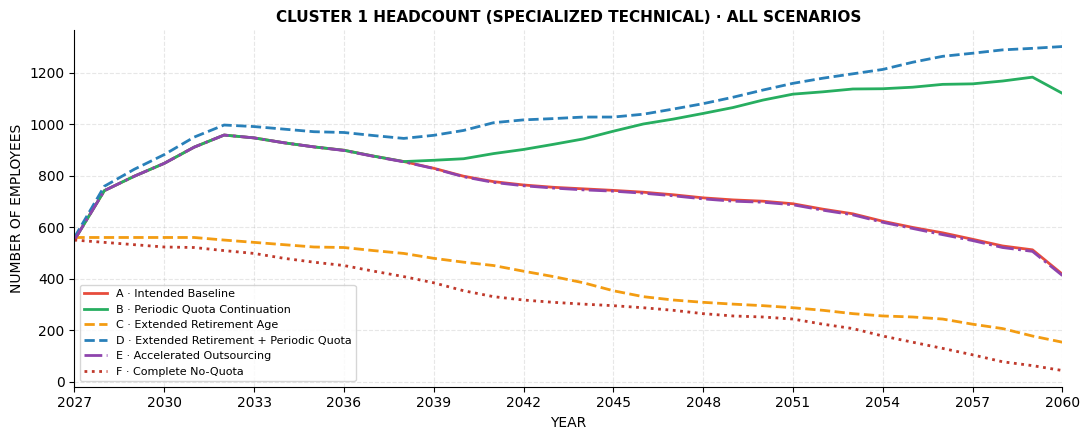

In [36]:
# CROSS-SCENARIO COMPARISON — PLOT 6 · CLUSTER 1 HEADCOUNT · ALL SCENARIOS
SLABELS = {
    0: 'A · Intended Baseline',
    1: 'B · Periodic Quota Continuation',
    2: 'C · Extended Retirement Age',
    3: 'D · Extended Retirement + Periodic Quota',
    4: 'E · Accelerated Outsourcing',
    5: 'F · Complete No-Quota',
}
SCOLOURS = {
    0: '#E74C3C',
    1: '#27AE60',
    2: '#F39C12',
    3: '#2980B9',
    4: '#8E44AD',
    5: '#C0392B',
}
LSTYLES = {
    0: '-',
    1: '-',
    2: '--',
    3: '--',
    4: '-.',
    5: ':',
}
fig, ax = plt.subplots(figsize=(11, 4.5))
for sid, l in SLABELS.items():
    df = master[master['scenarioID'] == sid].copy()
    ax.plot(df['year'], df['count_1'], color=SCOLOURS[sid], linewidth=2, linestyle=LSTYLES[sid], label=l)
ax.set_title('CLUSTER 1 HEADCOUNT (SPECIALIZED TECHNICAL) · ALL SCENARIOS', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2027, 2060)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

___
**END**